In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [4]:
gradients = torch.load("./local_data/gradient_vectors.pt").to(DEVICE)
token_counts = torch.load("./local_data/token_counts.pt").to(DEVICE)

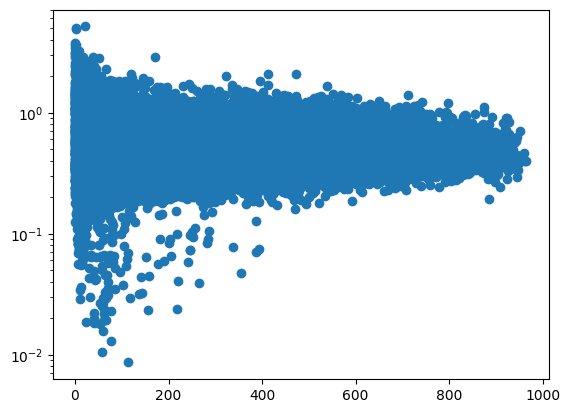

In [63]:

norms = torch.norm(gradients, dim=1) * token_counts

plt.scatter(token_counts.cpu(), (norms / torch.sqrt(token_counts)).cpu())
plt.yscale("log")
plt.show()

tensor(0.0569, device='cuda:0')
tensor([-0.0679, -0.0483, -0.0159,  ..., -0.0173,  0.1957,  0.0365],
       device='cuda:0')
tensor([ 1.8966,  0.1354,  0.1350,  ...,  0.1495, -0.4882, -2.2419],
       device='cuda:0')
tensor([-4.3490, -2.2004, -1.2104,  ...,  0.3002, -0.2187,  0.8826],
       device='cuda:0')
tensor([-0.0578, -0.0454, -0.0222,  ...,  0.0432, -0.0113,  0.0147],
       device='cuda:0')


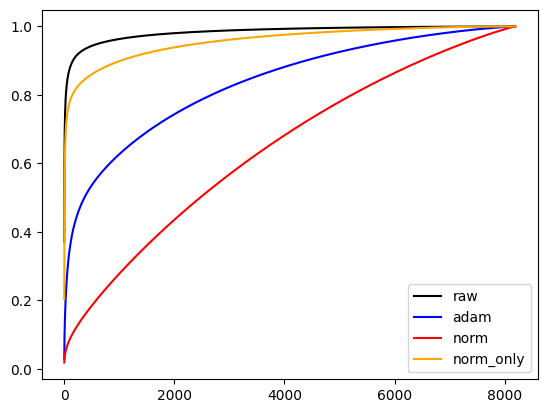

In [54]:
def process(x):
    # return x
    return x - x.mean(0)

def adam_norm(x):
    return x * torch.rsqrt(x.pow(2).mean(0) + 1e-12)

def get_spectra(x):
    hessian = (x.T @ x) / (len(x) - 1)
    eig_vals, eig_vecs = torch.linalg.eigh(hessian.double())
    eig_vals, eig_vecs = eig_vals.float(), eig_vecs.float()
    # print the eigenvector with the largest eigenvalue
    print(eig_vecs[:, -1] * np.sqrt(x.shape[-1]))
    return eig_vals

def explained_variance(spectra):
    # return spectra / spectra.sum()
    return torch.cumsum(spectra.flip(0), dim=0) / spectra.sum()

print((gradients.pow(2).mean(0) < 1e-8).float().mean())

raw = get_spectra(process(gradients))
adam = get_spectra(adam_norm(process(gradients)))
norm = get_spectra(adam_norm(process(F.normalize(gradients, dim=1))))
norm_only = get_spectra(process(F.normalize(gradients, dim=1)))

plt.plot(explained_variance(raw).cpu(), label="raw", color="black")
plt.plot(explained_variance(adam).cpu(), label="adam", color="blue")
plt.plot(explained_variance(norm).cpu(), label="norm", color="red")
plt.plot(explained_variance(norm_only).cpu(), label="norm_only", color="orange")

plt.legend()
# plt.yscale("log")
plt.show()

tensor(0.0569, device='cuda:0')
tensor([-0.0679, -0.0483, -0.0159,  ..., -0.0173,  0.1957,  0.0365],
       device='cuda:0')
tensor([ 1.8966,  0.1354,  0.1350,  ...,  0.1495, -0.4882, -2.2419],
       device='cuda:0')
tensor([-4.3490, -2.2004, -1.2104,  ...,  0.3002, -0.2187,  0.8826],
       device='cuda:0')
tensor([-0.0578, -0.0454, -0.0222,  ...,  0.0432, -0.0113,  0.0147],
       device='cuda:0')


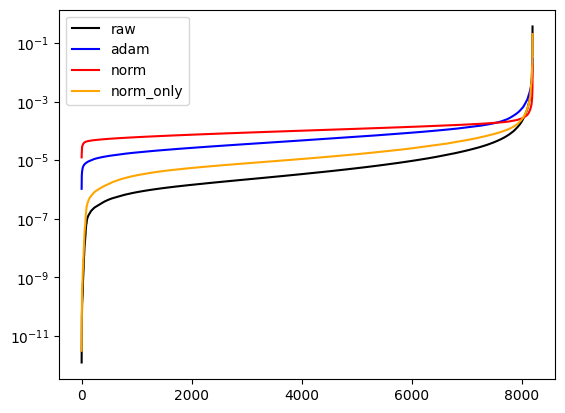

In [58]:
def process(x):
    # return x
    return x - x.mean(0)

def adam_norm(x):
    return x * torch.rsqrt(x.pow(2).mean(0) + 1e-12)

def get_spectra(x):
    hessian = (x.T @ x) / (len(x) - 1)
    eig_vals, eig_vecs = torch.linalg.eigh(hessian.double())
    eig_vals, eig_vecs = eig_vals.float(), eig_vecs.float()
    # print the eigenvector with the largest eigenvalue
    print(eig_vecs[:, -1] * np.sqrt(x.shape[-1]))
    return eig_vals

def explained_variance(spectra):
    return spectra / spectra.sum()
    # return torch.cumsum(spectra.flip(0), dim=0) / spectra.sum()

print((gradients.pow(2).mean(0) < 1e-8).float().mean())

raw = get_spectra(process(gradients))
adam = get_spectra(adam_norm(process(gradients)))
norm = get_spectra(adam_norm(process(F.normalize(gradients, dim=1, eps=1e-12))))
norm_only = get_spectra(process(F.normalize(gradients, dim=1)))

plt.plot(explained_variance(raw).cpu(), label="raw", color="black")
plt.plot(explained_variance(adam).cpu(), label="adam", color="blue")
plt.plot(explained_variance(norm).cpu(), label="norm", color="red")
plt.plot(explained_variance(norm_only).cpu(), label="norm_only", color="orange")

plt.legend()
plt.yscale("log")
plt.show()